In [1]:
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import keras
import librosa
import io
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img, img_to_array, array_to_img
from tensorflow.keras.applications.resnet import preprocess_input

# Download model ResNet50

In [2]:
base = tf.keras.applications.ResNet50(weights='imagenet',
                                           include_top= False,
                                           input_shape= (224,224,3),
                                           classes= 11)
print(base.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


In [3]:
base.trainable = False

# Model creation

In [4]:
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(11, activation='softmax')(x)
model = Model(inputs=base.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,403 (90.99 MB)

 Trainable params: 263,691 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Image preparation and dataframe validation for training

In [5]:
df = pd.read_csv('df_fixed.csv')
df

,en,file-name,label,png_path
0,European Free-tailed Bat,"XC1062164-Vavouledo-26Oct10-10-P.-han,-T.-ten_...",3,spectograms/XC1062164-Vavouledo-26Oct10-10-P.-...
1,European Free-tailed Bat,"XC1062157-Vavouledo-26Oct10-07-H.s_P.k,-P.-han...",3,spectograms/XC1062157-Vavouledo-26Oct10-07-H.s...
2,European Free-tailed Bat,XC1062125-Sasalo-stream-01Oct10-29_0_00005_000...,3,spectograms/XC1062125-Sasalo-stream-01Oct10-29...
3,European Free-tailed Bat,XC1061936-Orfeas-D500-14to15Oct2020-M01935.wav,3,spectograms/XC1061936-Orfeas-D500-14to15Oct202...
4,European Free-tailed Bat,XC1061935-Orfeas-D500-14to15Oct2020-M01501.wav,3,spectograms/XC1061935-Orfeas-D500-14to15Oct202...
...,...,...,...,...
1779,Western Barbastelle,XC822052-mops2216normalpassB.wav,10,spectograms/XC822052-mops2216normalpassB.png
1780,Western Barbastelle,XC822042-mops2212normal.wav,10,spectograms/XC822042-mops2212normal.png
1781,Western Barbastelle,XC822041-mops2213coll.wav,10,spectograms/XC822041-mops2213coll.png
1782,Western Barbastelle,XC805682-9_Car251310-2021-Pass1-C1-011693-SINI...,10,spectograms/XC805682-9_Car251310-2021-Pass1-C1...


In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", len(train_df), " Val:", len(val_df))

Train: 1427  Val: 357


In [11]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = keras.applications.resnet.preprocess_input(img)
    return img, label

In [12]:
BATCH_SIZE = 16

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['png_path'].values, df["label"].values)
    )
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(512)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)

In [ ]:
for imgs, labels in train_ds.take(5):
    print("Batch shape:", imgs.shape)
    print("Labels:", labels.numpy())

In [ ]:
img = imgs[0].numpy()
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.title(le.inverse_transform([labels[0].numpy()])[0])
plt.axis("off")
plt.show()

# Compile and fit

In [180]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,403 (90.99 MB)

 Trainable params: 263,691 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [181]:
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Num classes:", num_classes)

Train samples: 1427
Val samples: 357
Num classes: 11


In [182]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'baseline_resnet50_best.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

In [183]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.3041 - loss: 2.1697 - top_3_accuracy: 0.5746 - val_accuracy: 0.5686 - val_loss: 1.4734 - val_top_3_accuracy: 0.8067
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 433ms/step - accuracy: 0.5802 - loss: 1.3818 - top_3_accuracy: 0.8157 - val_accuracy: 0.6667 - val_loss: 1.1517 - val_top_3_accuracy: 0.8571
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 497ms/step - accuracy: 0.6580 - loss: 1.1085 - top_3_accuracy: 0.8584 - val_accuracy: 0.7199 - val_loss: 0.9813 - val_top_3_accuracy: 0.8852
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 546ms/step - accuracy: 0.6903 - loss: 0.9561 - top_3_accuracy: 0.8998 - val_accuracy: 0.7535 - val_loss: 0.8713 - val_top_3_accuracy: 0.9020
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 48s 528ms/step - accuracy: 0.7491 - loss: 0.8474 - top_3_accuracy: 0.9215 - val_accuracy: 0.7563 - val_loss: 0.8094 - val_top_3_accuracy: 0.8964
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 519ms/step - accuracy: 0.7786 - loss: 0.763

In [184]:
model.save('BatRN50.keras')

In [241]:
probs1=model.predict(val_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step


In [244]:
probs1.argmax(1)

array([ 7,  6,  6,  3,  0,  0,  4,  4,  3,  0,  7,  2,  3,  8, 10,  5,  7,
        0,  7,  2,  9,  1,  9,  2,  4,  4,  2,  8,  8,  4,  2,  4,  2,  2,
        7,  5,  0,  7,  8,  3,  4,  3,  7,  7,  3,  3,  8,  0,  6, 10,  2,
        4,  7,  7,  4,  0,  8,  7,  6,  7,  0,  6,  6,  0,  7,  7,  8,  7,
        6,  4,  6,  8,  6,  2,  4,  4,  3,  4,  0,  0,  9,  8,  0,  6,  1,
        7,  1,  7,  0, 10,  3,  1,  3,  8,  7,  0,  6,  7,  3,  3,  5,  0,
        0,  7,  8,  1,  0,  6,  3,  6,  3,  0,  7,  3,  0,  7,  8,  5,  3,
        4,  8,  0,  6,  3,  7,  7,  8,  8,  7,  9,  6,  3,  4,  0,  3,  3,
        6,  0,  9,  0,  0,  7,  2,  0,  9,  7,  0,  3,  8,  3,  1,  2,  4,
        1,  8,  6,  2,  0,  5,  4,  6,  4,  2,  0,  5,  0,  3,  2,  0,  3,
       10,  8,  9,  4,  7,  7,  7,  8,  3,  9,  0,  0,  7,  7,  8,  7,  4,
        0,  8,  8,  2,  4,  2,  3,  4,  6,  4,  8,  7,  3,  0,  8,  6,  3,
        4,  4, 10,  2,  0,  0,  8,  0,  3,  3,  4,  4,  7,  7,  7,  4,  8,
        4,  0,  5,  2,  1

In [246]:
val_df.head()

,en,file-name,label,png_path
1565,Savi's Pipistrelle,XC1058007-Hsavii-SOUDA-04_20210701_030254_000.wav,7,spectograms/XC1058007-Hsavii-SOUDA-04_20210701...
325,Lesser Horseshoe Bat,XC1038071-bct_woodland_hope_98_rhinolophus_hip...,6,spectograms/XC1038071-bct_woodland_hope_98_rhi...
313,Lesser Horseshoe Bat,XC1038086-bct_woodland_hope_113_rhinolophus_hi...,6,spectograms/XC1038086-bct_woodland_hope_113_rh...
217,European Free-tailed Bat,XC1057269-Tten-SOUDA-02_20210809_031132.wav,3,spectograms/XC1057269-Tten-SOUDA-02_20210809_0...
1118,Daubenton's Myotis,XC918932-61246484-7167-4872-a984-ebf13b64571a.wav,1,spectograms/XC918932-61246484-7167-4872-a984-e...


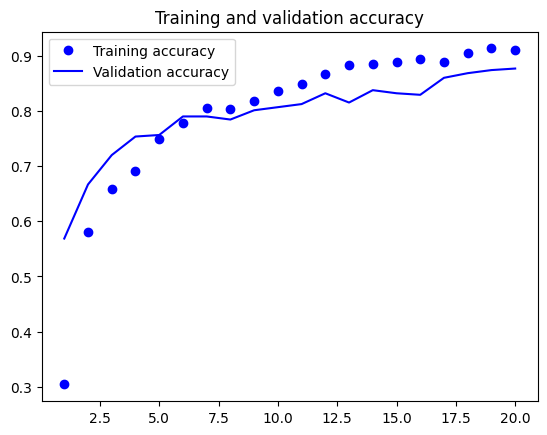

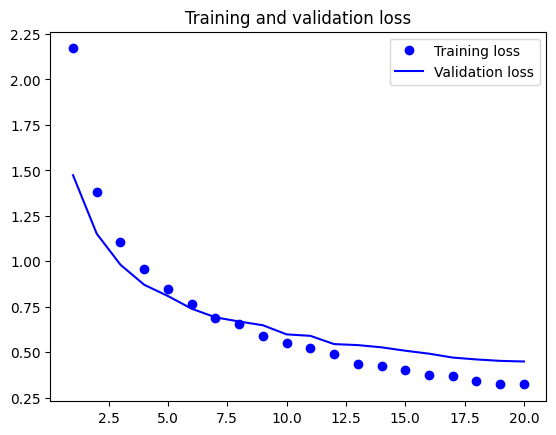

In [185]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy') 
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [187]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

In [188]:
cm = confusion_matrix(y_true, y_pred)

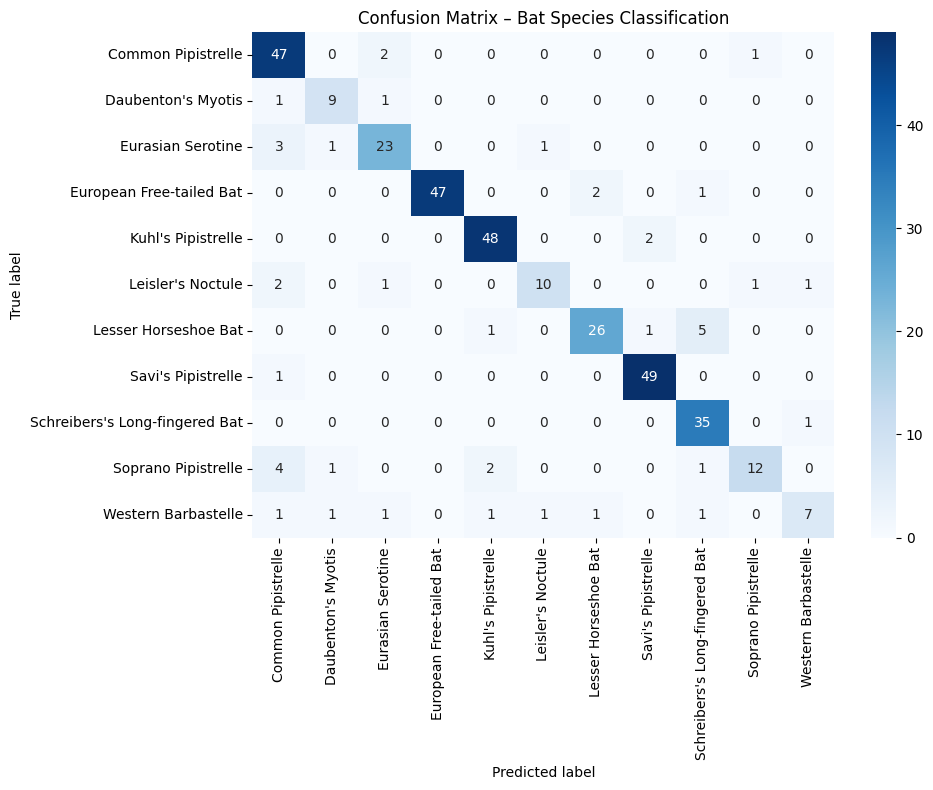

In [189]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Bat Species Classification")
plt.tight_layout()
plt.show()

# Function to test the model on other audios

In [214]:
def wav_to_spec(uploaded_file):
    DURATION   = 1.0  
    TARGET_SR  = 192000
    N_MELS     = 128
    N_FFT      = 4096
    HOP_LENGTH = 1024
    FMIN       = 15000

    #-----------Load audio-----------
    y, sr = librosa.load(uploaded_file, sr=192000, mono=True)
    
    target_len = 192000
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')

    #--------Mel spectrogram--------
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=sr//2,
        power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    #----Convert to image (no saving to disk)------

    fig = plt.figure(figsize=(3, 3), dpi=150)
    librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                             x_axis=None, y_axis=None, fmax=sr//2)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.axis('off')

    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    buf.seek(0)
    img = plt.imread(buf)

    return img